In [12]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [13]:
N_SPLITS = 4
TEST_SIZE = 0.6
SEED = 42
SAMPLE_SIZE = 10
TOP_FEATURES = 15

# Hyperparameter grid for XGBClassifier
PARAM_GRID = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5, 7],
    'xgbclassifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'xgbclassifier__min_child_weight': [1, 5, 10],
    'xgbclassifier__gamma': [0.5, 1, 1.5, 2, 5],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0]
}


In [14]:
def train_test_and_show_results(m_data: dict, tune_hyperparameters: bool = False, param_grid: dict = None, xgb_params: dict = None):

    # Track results for each fold
    fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], []
    class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

    best_params_per_fold = []  # Track best parameters per fold

    # Store ROC curve points for all folds
    roc_curves = []

    split_0_data = next(iter(m_data.values()))

    feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
    feature_names = feature_names.str.replace('original_', '', regex=False)

    for fold, split_data in m_data.items():
        print(f"\nFold {fold}:")
        print(f"Original train class distribution: {Counter(split_data['y_train'])}")
        print(f"Original test class distribution: {Counter(split_data['y_test'])}")

        if tune_hyperparameters:

            # Define the model with hyperparameter tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
            ])

            grid_search = GridSearchCV(model, param_grid=param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1_macro', n_jobs=-1)
            grid_search.fit(split_data['X_train'], split_data['y_train'])
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
            best_params_per_fold.append(best_params)  # Save best parameters
            print(f"Best parameters for fold {fold}: {best_params}")
        else:
            # Use provided xgb_params or default parameters if not tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(**(xgb_params or {}), random_state=SEED)),
            ])
            
            model.fit(split_data['X_train'], split_data['y_train'])
            best_model = model        

        # Extract feature importances from XGBoost
        xgb_model = best_model.named_steps['xgbclassifier']
        importances = xgb_model.feature_importances_

        # Evaluate on the test set
        preds = best_model.predict(split_data['X_test'])
        preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
        
        # Calculate metrics
        accuracy = accuracy_score(split_data['y_test'], preds)
        f1_macro = f1_score(split_data['y_test'], preds, average='macro')
        f1_micro = f1_score(split_data['y_test'], preds, average='micro')
        f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
        precision = precision_score(split_data['y_test'], preds)
        recall = recall_score(split_data['y_test'], preds)

        fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
        roc_auc = auc(fpr, tpr)

        # If auc is NaN, set to 0
        if np.isnan(roc_auc):
            roc_auc = 0
        
        roc_curves.append((fpr, tpr))

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

        # Print fold results
        print(f"\n\nFold {fold} results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-macro: {f1_macro:.4f}")
        print(f"F1-micro: {f1_micro:.4f}")
        print(f"F1-weighted: {f1_weighted:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
        print(f"Classification report:\n{classification_report(split_data['y_test'], preds)}")
        print("-" * 50)
        
        # Plot top k features for this fold
        # top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
        # top_importances = importances[top_indices]

        # plt.figure(figsize=(10, 3))
        # plt.subplot(1, 2, 1)
        # plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
        # plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
        # plt.ylabel("Feature Index")
        # plt.xlabel("Importance")
        # plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
        # # Plot confusion matrix
        # plt.subplot(1, 2, 2)
        # cm = confusion_matrix(split_data['y_test'], preds)
        # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        # plt.title(f'Confusion Matrix (Fold {fold})')
        # plt.xlabel('Predicted Label')
        # plt.ylabel('True Label')
        # plt.tight_layout()
        # plt.show()

        # Track results
        fold_accuracies.append(accuracy)
        fold_f1_macros.append(f1_macro)
        fold_f1_micros.append(f1_micro)
        fold_f1_weighted.append(f1_weighted)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_roc_aucs.append(roc_auc)
        feature_importances.append(importances)

        class_metrics['true_positives'].append(tp)
        class_metrics['false_negatives'].append(fn)
        class_metrics['false_positives'].append(fp)
        class_metrics['true_negatives'].append(tn)

    print(f"\nAll Folds Completed.")
    print("\n--------------------------------------------------")
    print("\nSummary of Results:\n")

    # Display best parameters summary
    if tune_hyperparameters:
        print("\nBest parameters per fold:")
        for fold, params in enumerate(best_params_per_fold):
            print(f"Fold {fold}: {params}")

    # Plotting ROC and Precision-Recall curves side by side
    plt.figure(figsize=(15, 5))

    # ROC Curve Plot
    plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
    for i, (fpr, tpr) in enumerate(roc_curves):
        plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
    plt.title("ROC Curve Across Folds")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    # Calculate mean importances across folds
    mean_importances = np.mean(feature_importances, axis=0)
    # Get indices of the top k features by mean
    top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
    top_importances_mean = mean_importances[top_indices_mean]

    plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
    plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

    # Display the plots side by side
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

    # Display summary statistics across folds
    print(f"\nSummary Across Folds:")
    print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
    print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
    print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
    print(f"Mean precision: {np.mean(fold_precisions):.4f}")
    print(f"Mean recall: {np.mean(fold_recalls):.4f}")
    print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")

    # Show top feature importances
    print("\nTop Feature Importances (Mean):")
    for i, idx in enumerate(top_indices_mean):
        print(f"{i + 1}. {feature_names[idx]}: {top_importances_mean[i]:.4f}")

    # Optional: Calculate the most common parameters across folds
    if tune_hyperparameters:
        most_comon_params = max(set(best_params_per_fold), key=best_params_per_fold.count)
        print("\nMost common parameters across folds:")
        print(most_comon_params)

In [15]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
df = dataclass.df


Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})


Fold 0 results:
Accuracy: 0.8158
F1-macro: 0.5970
F1-micro: 0.8158
F1-weighted: 0.7767
Precision: 0.6000
Recall: 0.2000
ROC AUC: 0.6284
True Positives: 3, False Negatives: 12, False Positives: 2, True Negatives: 59
Classification report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89        61
           1       0.60      0.20      0.30        15

    accuracy                           0.82        76
   macro avg       0.72      0.58      0.60        76
weighted avg       0.79      0.82      0.78        76

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 125, 1: 29})
Original test class distribution: Counter({0: 58, 1: 18})


Fold 1 results:
Accuracy: 0.7368
F1-macro: 0.6360
F1-micro: 0.7368
F1-weighted: 0.7368
Precision: 0.4444
Recall: 0.4444
ROC AUC

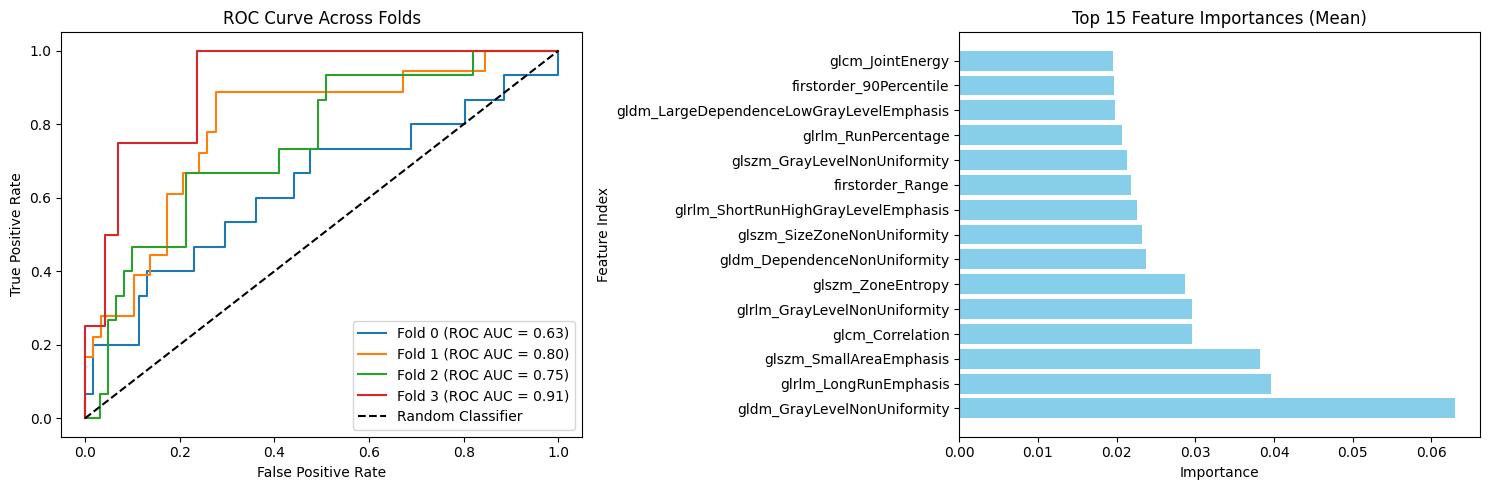


Summary Across Folds:
Mean accuracy: 0.8026
Mean F1-macro: 0.6172
Mean F1-micro: 0.8026
Mean F1-weighted: 0.7952
Mean precision: 0.4319
Mean recall: 0.3403
Mean ROC AUC: 0.7710

Top Feature Importances (Mean):
1. gldm_GrayLevelNonUniformity: 0.0630
2. glrlm_LongRunEmphasis: 0.0396
3. glszm_SmallAreaEmphasis: 0.0382
4. glcm_Correlation: 0.0296
5. glrlm_GrayLevelNonUniformity: 0.0295
6. glszm_ZoneEntropy: 0.0287
7. gldm_DependenceNonUniformity: 0.0237
8. glszm_SizeZoneNonUniformity: 0.0232
9. glrlm_ShortRunHighGrayLevelEmphasis: 0.0225
10. firstorder_Range: 0.0218
11. glszm_GrayLevelNonUniformity: 0.0213
12. glrlm_RunPercentage: 0.0206
13. gldm_LargeDependenceLowGrayLevelEmphasis: 0.0197
14. firstorder_90Percentile: 0.0196
15. glcm_JointEnergy: 0.0196


In [16]:
m_data = DataSplitting.expanding_window_split(df, 4)

#train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
train_test_and_show_results(m_data, tune_hyperparameters=False, xgb_params= {'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
})

In [17]:
xgb_params = {
 'xgbclassifier__colsample_bytree': 0.6,
 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
}

Total groups: 18, Test groups: 10

Fold 0:
Original train class distribution: Counter({0: 234, 1: 52})
Original test class distribution: Counter({0: 82, 1: 14})


Fold 0 results:
Accuracy: 0.8438
F1-macro: 0.5990
F1-micro: 0.8438
F1-weighted: 0.8209
Precision: 0.4286
Recall: 0.2143
ROC AUC: 0.7605
True Positives: 3, False Negatives: 11, False Positives: 4, True Negatives: 78
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        82
           1       0.43      0.21      0.29        14

    accuracy                           0.84        96
   macro avg       0.65      0.58      0.60        96
weighted avg       0.81      0.84      0.82        96

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 260, 1: 48})
Original test class distribution: Counter({0: 56, 1: 18})


Fold 1 results:
Accuracy: 0.7703
F1-macro: 0.5909
F1-micro: 0.7703
F1-weighted: 0.7300
Preci

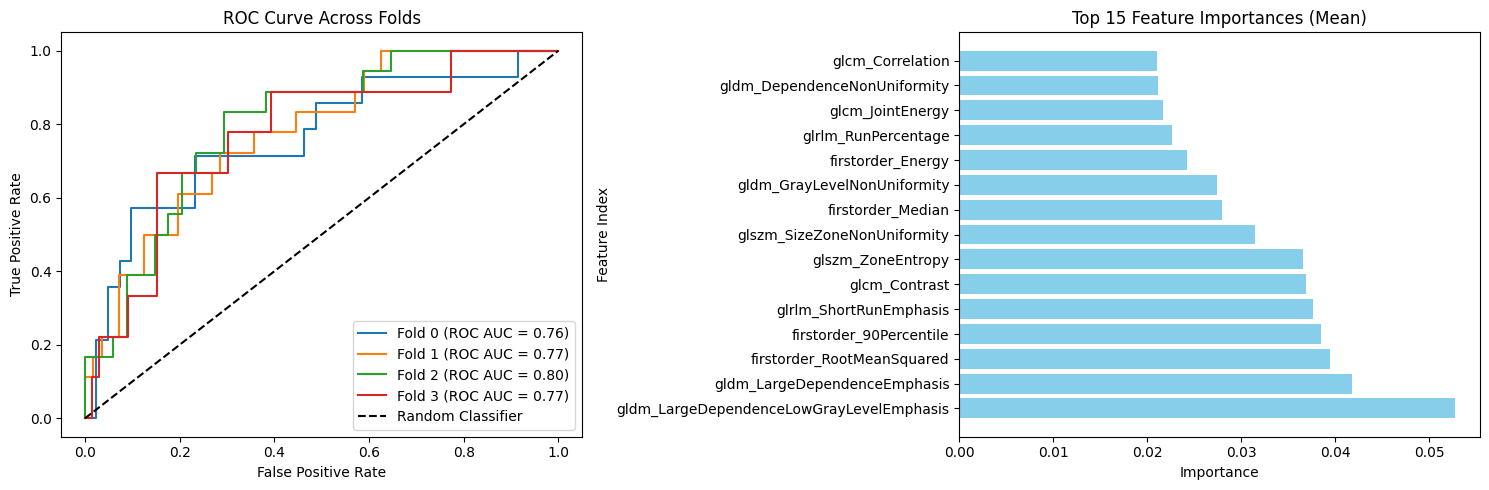


Summary Across Folds:
Mean accuracy: 0.7866
Mean F1-macro: 0.5875
Mean F1-micro: 0.7866
Mean F1-weighted: 0.7529
Mean precision: 0.5208
Mean recall: 0.2341
Mean ROC AUC: 0.7759

Top Feature Importances (Mean):
1. gldm_LargeDependenceLowGrayLevelEmphasis: 0.0527
2. gldm_LargeDependenceEmphasis: 0.0417
3. firstorder_RootMeanSquared: 0.0394
4. firstorder_90Percentile: 0.0385
5. glrlm_ShortRunEmphasis: 0.0376
6. glcm_Contrast: 0.0369
7. glszm_ZoneEntropy: 0.0366
8. glszm_SizeZoneNonUniformity: 0.0314
9. firstorder_Median: 0.0279
10. gldm_GrayLevelNonUniformity: 0.0275
11. firstorder_Energy: 0.0242
12. glrlm_RunPercentage: 0.0226
13. glcm_JointEnergy: 0.0217
14. gldm_DependenceNonUniformity: 0.0211
15. glcm_Correlation: 0.0210


In [18]:
m_data = DataSplitting.split_data_population_informed(df=df, seed=SEED, n_splits=N_SPLITS, test_size=TEST_SIZE)

train_test_and_show_results(m_data, tune_hyperparameters=False, xgb_params=xgb_params)



Fold 0:
Original train class distribution: Counter({0: 124, 1: 30})
Original test class distribution: Counter({0: 48, 1: 9})


Fold 0 results:
Accuracy: 0.7018
F1-macro: 0.5645
F1-micro: 0.7018
F1-weighted: 0.7318
Precision: 0.2500
Recall: 0.4444
ROC AUC: 0.5093
True Positives: 4, False Negatives: 5, False Positives: 12, True Negatives: 36
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        48
           1       0.25      0.44      0.32         9

    accuracy                           0.70        57
   macro avg       0.56      0.60      0.56        57
weighted avg       0.78      0.70      0.73        57

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 168, 1: 39})
Original test class distribution: Counter({0: 48, 1: 9})


Fold 1 results:
Accuracy: 0.8421
F1-macro: 0.6093
F1-micro: 0.8421
F1-weighted: 0.8156
Precision: 0.5000
Recall: 0.2222
ROC AUC:

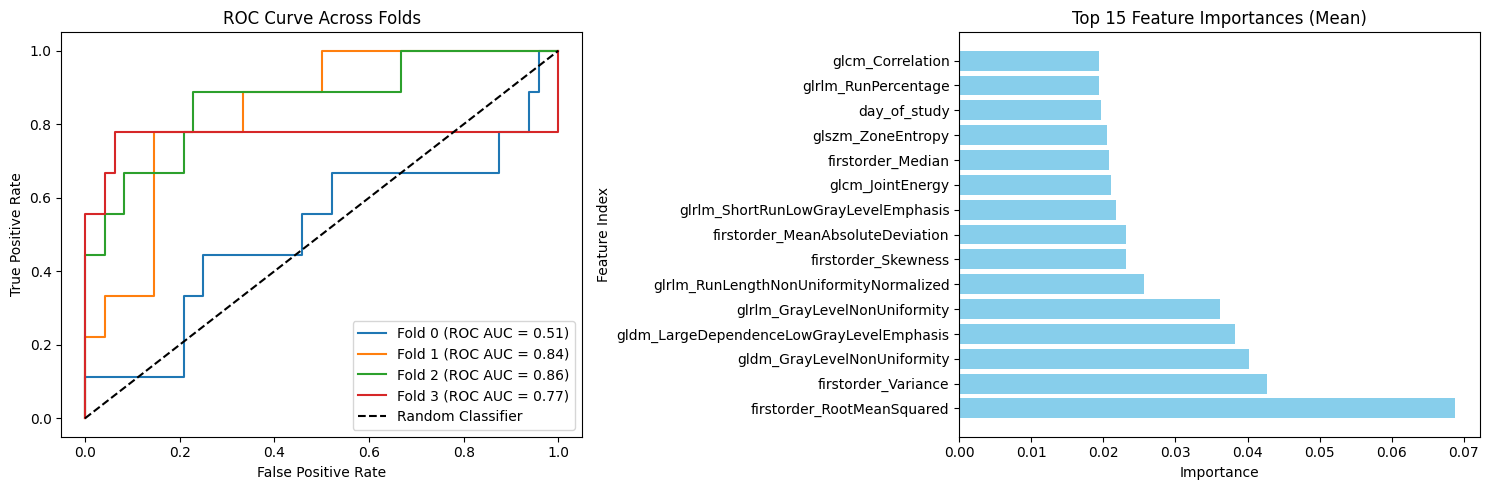


Summary Across Folds:
Mean accuracy: 0.8377
Mean F1-macro: 0.6781
Mean F1-micro: 0.8377
Mean F1-weighted: 0.8317
Mean precision: 0.6375
Mean recall: 0.3889
Mean ROC AUC: 0.7442

Top Feature Importances (Mean):
1. firstorder_RootMeanSquared: 0.0688
2. firstorder_Variance: 0.0427
3. gldm_GrayLevelNonUniformity: 0.0402
4. gldm_LargeDependenceLowGrayLevelEmphasis: 0.0382
5. glrlm_GrayLevelNonUniformity: 0.0362
6. glrlm_RunLengthNonUniformityNormalized: 0.0256
7. firstorder_Skewness: 0.0232
8. firstorder_MeanAbsoluteDeviation: 0.0231
9. glrlm_ShortRunLowGrayLevelEmphasis: 0.0217
10. glcm_JointEnergy: 0.0211
11. firstorder_Median: 0.0208
12. glszm_ZoneEntropy: 0.0204
13. day_of_study: 0.0196
14. glrlm_RunPercentage: 0.0195
15. glcm_Correlation: 0.0193


In [19]:
m_data = DataSplitting.expanding_window_split_by_mice_group(df=df, n_splits=N_SPLITS)

train_test_and_show_results(m_data, tune_hyperparameters=False, xgb_params=xgb_params)

Total possible combinations: 3060
Generated 10 sampled combinations.

Fold 0:
Original train class distribution: Counter({0: 301, 1: 29})
Original test class distribution: Counter({1: 37, 0: 15})


Fold 0 results:
Accuracy: 0.4615
F1-macro: 0.4543
F1-micro: 0.4615
F1-weighted: 0.4276
Precision: 1.0000
Recall: 0.2432
ROC AUC: 0.7135
True Positives: 9, False Negatives: 28, False Positives: 0, True Negatives: 15
Classification report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        15
           1       1.00      0.24      0.39        37

    accuracy                           0.46        52
   macro avg       0.67      0.62      0.45        52
weighted avg       0.81      0.46      0.43        52

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 212, 1: 66})
Original test class distribution: Counter({0: 104})


Fold 1 results:
Accuracy: 0.7308
F1-macro: 0.4222
F1-micro: 0.7

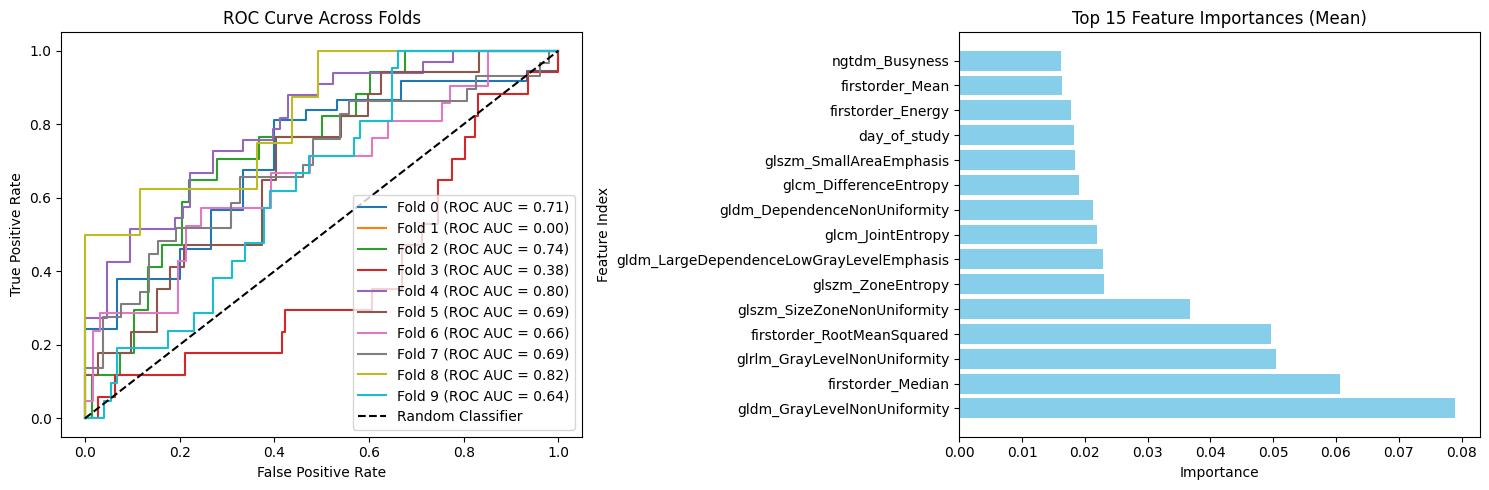


Summary Across Folds:
Mean accuracy: 0.6835
Mean F1-macro: 0.5267
Mean F1-micro: 0.6835
Mean F1-weighted: 0.6942
Mean precision: 0.4257
Mean recall: 0.2794
Mean ROC AUC: 0.6137

Top Feature Importances (Mean):
1. gldm_GrayLevelNonUniformity: 0.0790
2. firstorder_Median: 0.0607
3. glrlm_GrayLevelNonUniformity: 0.0504
4. firstorder_RootMeanSquared: 0.0496
5. glszm_SizeZoneNonUniformity: 0.0368
6. glszm_ZoneEntropy: 0.0231
7. gldm_LargeDependenceLowGrayLevelEmphasis: 0.0228
8. glcm_JointEntropy: 0.0219
9. gldm_DependenceNonUniformity: 0.0213
10. glcm_DifferenceEntropy: 0.0191
11. glszm_SmallAreaEmphasis: 0.0185
12. day_of_study: 0.0183
13. firstorder_Energy: 0.0177
14. firstorder_Mean: 0.0164
15. ngtdm_Busyness: 0.0162


In [20]:
m_data = DataSplitting.grouped_combinations_split_with_sampling(df=df, n_splits=N_SPLITS, sample_size=SAMPLE_SIZE, seed=SEED)
print(f"Generated {len(m_data)} sampled combinations.")

train_test_and_show_results(m_data, tune_hyperparameters=False, xgb_params=xgb_params)